## **Projet - Inférence automatique de la relation entre deux phrases**

### **Importation des packages**

In [1]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import seaborn as sn
import os
import torch

import warnings
warnings.filterwarnings("ignore")

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer
)
import logging
import transformers
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login; login(token=UserSecretsClient().get_secret("HF_TOKEN")) #Les modèles Llama requièrent une licence.
from peft import LoraConfig, get_peft_model
from transformers import DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score, classification_report

2026-01-02 16:22:12.049285: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767370932.548007      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767370932.684229      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767370933.826277      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767370933.826314      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767370933.826317      55 computation_placer.cc:177] computation placer alr

### **Importation des données**

In [2]:
#Importation des données
train = pd.read_table('../input/learning-dataset/nli_fr_train.tsv')
test = pd.read_table('../input/learning-dataset/nli_fr_test.tsv')
print("--- Dataset Info ---")
print("Shape of train data : ", train.shape)
print("Shape of test data : ", test.shape)
print(train.head())

--- Dataset Info ---
Shape of train data :  (5010, 3)
Shape of test data :  (2490, 3)
                                          -e premise  \
0  Eh bien, je ne pensais même pas à cela, mais j...   
1  Eh bien, je ne pensais même pas à cela, mais j...   
2  Eh bien, je ne pensais même pas à cela, mais j...   
3  Et je pensais que c'était un privilège, et ça ...   
4  Et je pensais que c'était un privilège, et ça ...   

                                                hypo          label  
0                  Je ne lui ai pas parlé de nouveau  contradiction  
1  J'étais si contrarié que je commençais juste à...     entailment  
2               Nous avons eu une grande discussion.        neutral  
3  Je n'avais pas conscience que je n'étais pas l...        neutral  
4  J'avais l'impression que j'étais le seul à avo...     entailment  


### **Exploration des données**

--- Label Histogram---


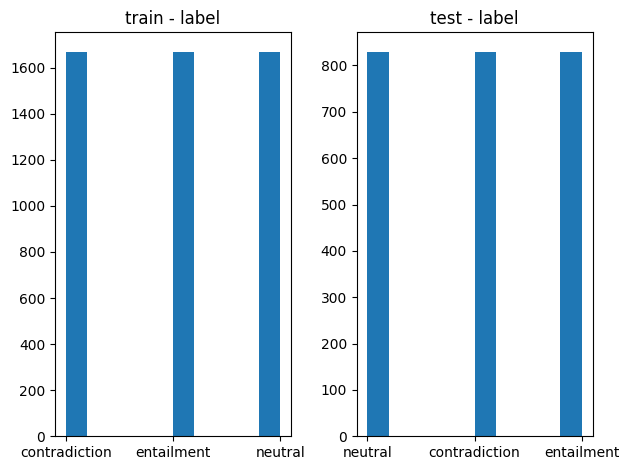

In [4]:
#Exploration des données - Équilibre des classes

print("--- Label Histogram---")
fig, axes = plt.subplots(1, 2)
axes[0].hist(train['label'])
axes[0].set_title('train - label')

axes[1].hist(test['label'])
axes[1].set_title('test - label')

plt.tight_layout()
plt.savefig("classes_imbalance.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
#Exploration des données - Longueur des phrases - Entailment

print("--- Sentences Length ---")
len_df = pd.DataFrame(columns=["len_premise_entail", "len_hypo_entail"])

len_df["len_premise_entail"] = train[train.label=="entailment"]["-e premise"].str.split().str.len()
len_df["len_hypo_entail"] = train[train.label=="entailment"]["hypo"].str.split().str.len()

len_df[["len_premise_entail", "len_hypo_entail"]].describe()

--- Sentences Length ---


,len_premise_entail,len_hypo_entail
count,1670.000000,1670.000000
mean,20.162874,9.629341
std,9.379353,4.009841
min,2.000000,2.000000
25%,13.000000,7.000000
50%,19.000000,9.000000
75%,27.000000,12.000000
max,48.000000,36.000000


In [6]:
#Exploration des données - Longueur des phrases - Contradiction

print("--- Sentences Length ---")
len_df = pd.DataFrame(columns=["len_premise_contra", "len_hypo_contra"])

len_df["len_premise_contra"] = train[train.label=="contradiction"]["-e premise"].str.split().str.len()
len_df["len_hypo_contra"] = train[train.label=="contradiction"]["hypo"].str.split().str.len()

len_df[["len_premise_contra", "len_hypo_contra"]].describe()

--- Sentences Length ---


,len_premise_contra,len_hypo_contra
count,1670.000000,1670.000000
mean,20.162874,10.195210
std,9.379353,4.074675
min,2.000000,2.000000
25%,13.000000,7.000000
50%,19.000000,10.000000
75%,27.000000,13.000000
max,48.000000,33.000000


In [7]:
#Exploration des données - Longueur des phrases - Neutral

print("--- Sentences Length ---")
len_df = pd.DataFrame(columns=["len_premise_neut", "len_hypo_neut"])

len_df["len_premise_neut"] = train[train.label=="neutral"]["-e premise"].str.split().str.len()
len_df["len_hypo_neut"] = train[train.label=="neutral"]["hypo"].str.split().str.len()

len_df[["len_premise_neut", "len_hypo_neut"]].describe()

--- Sentences Length ---


,len_premise_neut,len_hypo_neut
count,1670.000000,1670.000000
mean,20.162874,11.223952
std,9.379353,4.335830
min,2.000000,2.000000
25%,13.000000,8.000000
50%,19.000000,11.000000
75%,27.000000,14.000000
max,48.000000,37.000000


In [8]:
#Exploration des données - Mots fréquents par classe

from nltk.corpus import stopwords

clean_df = train.copy()

stop = set(stopwords.words("french"))

#Retrait des mots vides
clean_df["hyp_clean"] = (
    clean_df["hypo"]
      .str.lower()
      .str.split()
      .apply(lambda w: [x for x in w if x not in stop])
)

from collections import Counter

def get_counts(series, n=10):
    return Counter([w for row in series for w in row]).most_common(n)

#Décompte des mots les plus fréquents
top_entail = get_counts(clean_df[clean_df.label=="entailment"].hyp_clean)
top_contra = get_counts(clean_df[clean_df.label=="contradiction"].hyp_clean)
top_neut = get_counts(clean_df[clean_df.label=="neutral"].hyp_clean)
print("--- Most common Words - Entailment ---")
print(top_entail)
print("--- Most common Words - Contradiction ---")
print(top_contra)
print("--- Most common Words - Neutral ---")
print(top_neut)

--- Most common Words - Entailment ---
[('a', 291), ('plus', 74), ('beaucoup', 51), ("j'ai", 47), ('dit', 46), ('être', 46), ("c'est", 43), ('si', 39), ('gens', 39), ('faire', 36)]
--- Most common Words - Contradiction ---
[('a', 270), ('jamais', 151), ("n'a", 124), ("n'y", 88), ('tout', 85), ('plus', 68), ('tous', 58), ('aucun', 58), ('rien', 55), ("n'est", 52)]
--- Most common Words - Neutral ---
[('a', 266), ('plus', 123), ("qu'il", 65), ('parce', 62), ('si', 62), ('gens', 59), ('être', 56), ('tous', 47), ('beaucoup', 46), ("j'ai", 42)]


### **Implémentation des différentes méthodologies**

In [3]:
#Préparation des datasets

df_train = train.copy()
df_test = test.copy()

#Encodage des classes
label2id = {
    "contradiction": 0,
    "entailment": 1,
    "neutral": 2
}
id2label = {v: k for k, v in label2id.items()}

df_train["label"] = df_train["label"].map(label2id)
df_test["label"] = df_test["label"].map(label2id)

In [10]:
#Fonction pour la tokenization

def tokenize_fn(example, tokenizer):
    return tokenizer(
        example["-e premise"],
        example["hypo"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

#Fonction pour l'évaluation des performances

def compute_metrics(pred):
    logits, labels = pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

#### **Méthode LoRA et CamenBERT 2.0**

In [12]:
# ----------------------------
# 1. Création des datasets
# ----------------------------

train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_test)

# ----------------------------
# 2. Tokenizer CamemBERT 2.0
# ----------------------------
model_name = "almanach/camembertv2-base" #Nom du modèle tel qu'écrit sur huggingface
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = train_dataset.map(tokenize_fn, batched=True, fn_kwargs={"tokenizer": tokenizer})
test_dataset = test_dataset.map(tokenize_fn, batched=True, fn_kwargs={"tokenizer": tokenizer})

train_dataset = train_dataset.remove_columns(["-e premise", "hypo"])
test_dataset = test_dataset.remove_columns(["-e premise", "hypo"])

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset = train_dataset.with_format("torch")
test_dataset = test_dataset.with_format("torch")

# ----------------------------
# 3. Charger le modèle + LoRA
# ----------------------------
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    torch_dtype=torch.float32,
    device_map="auto"
)

lora_config = LoraConfig(
    r=8,                   #rang des matrices 
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_CLS",
    target_modules=["query", "value"] #Les couches où les matrices de rang faible seront injectées
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# ----------------------------
# 4. Entraînement
# ----------------------------
training_args = TrainingArguments(
    output_dir="./camembert_lora_nli",
    bf16=False,
    fp16=False,
    learning_rate=3e-4,              #Le taux d'apprentissage
    per_device_train_batch_size=1,   #Permet d'éviter les problèmes de type (Out of Memory)
    gradient_accumulation_steps=32,  
    eval_strategy="epoch",
    save_strategy="no",              #Nous permet d'éviter des problèmes de mémoire
    num_train_epochs=4,
    weight_decay=0.01,
    logging_steps=10,                
    load_best_model_at_end=False,    #Car les modèles ne sont pas sauvegardés
    optim="adamw_torch",             
    report_to="none"                
)

#Intéressant pour la vitesse
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

camembert_trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,     
    processing_class=tokenizer,    
)

#Lancement de l'apprentissage
print("Lancement imminent du moteur de calcul...")
camembert_trainer.train()

# ----------------------------
# 5. Évaluation détaillée
# ----------------------------
predictions = camembert_trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(axis=-1)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Macro-F1:", f1_score(y_true, y_pred, average="macro"))
print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=label2id.keys()))


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/963 [00:00<?, ?B/s]

Map:   0%|          | 0/5010 [00:00<?, ? examples/s]

Map:   0%|          | 0/2490 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/447M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at almanach/camembertv2-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The model is already on multiple devices. Skipping the move to device specified in `args`.


trainable params: 887,811 || all params: 112,490,502 || trainable%: 0.7892
Lancement imminent du moteur de calcul...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.092100,1.080054,0.410442,0.353884
2,0.866200,0.827019,0.634538,0.633375
3,0.711900,0.738478,0.691968,0.693341
4,0.729000,0.729546,0.700000,0.699708


Accuracy: 0.7
Macro-F1: 0.6997078662722207

Classification report:

               precision    recall  f1-score   support

contradiction       0.74      0.71      0.72       830
   entailment       0.72      0.76      0.74       830
      neutral       0.64      0.63      0.64       830

     accuracy                           0.70      2490
    macro avg       0.70      0.70      0.70      2490
 weighted avg       0.70      0.70      0.70      2490



#### **Méthode LoRA et CamenBERTa 2.0**

In [13]:
# ----------------------------
# 1. Création des datasets
# ----------------------------

train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_test)

# ----------------------------
# 2. Tokenizer CamemBERT 2.0
# ----------------------------
model_name = "almanach/camembertav2-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = train_dataset.map(tokenize_fn, batched=True, fn_kwargs={"tokenizer": tokenizer})
test_dataset = test_dataset.map(tokenize_fn, batched=True, fn_kwargs={"tokenizer": tokenizer})

train_dataset = train_dataset.remove_columns(["-e premise", "hypo"])
test_dataset = test_dataset.remove_columns(["-e premise", "hypo"])

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset = train_dataset.with_format("torch")
test_dataset = test_dataset.with_format("torch")

# ----------------------------
# 3. Charger le modèle + LoRA
# ----------------------------
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    torch_dtype=torch.float32,
    device_map="auto"
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_CLS",
    target_modules=["query", "key", "value", "dense"]   #Diffère du CamemBERT
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# ----------------------------
# 4. Entraînement
# ----------------------------
training_args = TrainingArguments(
    output_dir="./camemberta_lora_nli",  
    bf16=False,
    fp16=False,
    learning_rate=3e-4,
    per_device_train_batch_size=1,   
    gradient_accumulation_steps=32,
    eval_strategy="epoch",
    save_strategy="no",
    num_train_epochs=4,
    weight_decay=0.01,
    logging_steps=10,                
    load_best_model_at_end=False,  
    optim="adamw_torch",             
    report_to="none"                
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

camemberta_trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,     
    processing_class=tokenizer,      
)

#Lancement de l'apprentissage
print("Lancement imminent du moteur de calcul...")
camemberta_trainer.train()

# ----------------------------
# 5. Évaluation détaillée
# ----------------------------
predictions = camemberta_trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(axis=-1)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Macro-F1:", f1_score(y_true, y_pred, average="macro"))
print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=label2id.keys()))


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/963 [00:00<?, ?B/s]

Map:   0%|          | 0/5010 [00:00<?, ? examples/s]

Map:   0%|          | 0/2490 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at almanach/camembertav2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The model is already on multiple devices. Skipping the move to device specified in `args`.


trainable params: 899,331 || all params: 112,108,806 || trainable%: 0.8022
Lancement imminent du moteur de calcul...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.005500,0.848938,0.635743,0.622036
2,0.659300,0.593868,0.775904,0.775784
3,0.504300,0.587424,0.779116,0.779778
4,0.524200,0.590589,0.788353,0.788612


Accuracy: 0.7883534136546185
Macro-F1: 0.788612480141954

Classification report:

               precision    recall  f1-score   support

contradiction       0.80      0.81      0.81       830
   entailment       0.83      0.81      0.82       830
      neutral       0.73      0.75      0.74       830

     accuracy                           0.79      2490
    macro avg       0.79      0.79      0.79      2490
 weighted avg       0.79      0.79      0.79      2490



#### **Méthode LoRA et Llama 3 1B**

In [11]:
# ----------------------------
# 1. Préparation des Datasets
# ----------------------------
train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_test)

# ----------------------------
# 2. Tokenizer Llama 3
# ----------------------------
model_name = "meta-llama/Llama-3.2-1B" 
tokenizer = AutoTokenizer.from_pretrained(model_name)

#Padding End of sentence nécessaire pour les décodeurs
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

train_dataset = train_dataset.map(tokenize_fn, batched=True, fn_kwargs={"tokenizer": tokenizer})
test_dataset = test_dataset.map(tokenize_fn, batched=True, fn_kwargs={"tokenizer": tokenizer})

train_dataset = train_dataset.remove_columns(["-e premise", "hypo"])
test_dataset = test_dataset.remove_columns(["-e premise", "hypo"])

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset = train_dataset.with_format("torch")
test_dataset = test_dataset.with_format("torch")

# ----------------------------
# 3. Charger le Modèle + LoRA
# ----------------------------
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    torch_dtype=torch.float32,
    device_map="auto"
)

# Configuration du pad_token_id dans le modèle
model.config.pad_token_id = tokenizer.pad_token_id

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_CLS",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",])

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# ----------------------------
# 4. Entraînement
# ----------------------------
training_args = TrainingArguments(
    output_dir="./llama3_lora_nli",  
    bf16=False,
    fp16=False,
    learning_rate=3e-4,              
    per_device_train_batch_size=1,   
    gradient_accumulation_steps=32,  
    eval_strategy="epoch",
    save_strategy="no",
    num_train_epochs=4,
    weight_decay=0.01,
    logging_steps=10,
    load_best_model_at_end=False,
    optim="adamw_torch",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    processing_class=tokenizer,
)

#Lancement de l'apprentissage
print("Lancement imminent du moteur de calcul...")
trainer.train()

# ----------------------------
# 5. Évaluation
# ----------------------------
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(axis=-1)

print("\n--- Résultats Llama 3 ---")
print(classification_report(y_true, y_pred, target_names=label2id.keys()))

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Map:   0%|          | 0/5010 [00:00<?, ? examples/s]

Map:   0%|          | 0/2490 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at meta-llama/Llama-3.2-1B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 5,642,240 || all params: 1,241,462,784 || trainable%: 0.4545
Lancement imminent du moteur de calcul...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,21.598100,0.656349,0.736948,0.718758
2,11.545200,0.565951,0.784337,0.780581
3,4.312900,0.864541,0.802008,0.801712
4,3.190300,1.906277,0.795984,0.796591



--- Résultats Llama 3 ---
               precision    recall  f1-score   support

contradiction       0.85      0.81      0.83       830
   entailment       0.81      0.81      0.81       830
      neutral       0.73      0.77      0.75       830

     accuracy                           0.80      2490
    macro avg       0.80      0.80      0.80      2490
 weighted avg       0.80      0.80      0.80      2490



#### **Mode 0-shot et Llama 3 3B**

In [16]:
# --------------------------------------------
# 1. Fonction de génération du prompt (0-shot)
# --------------------------------------------

#Dans cette fonction on formule le prompt en structurant la question et la forme de la réponse
#que le modèle devrait retourner.
def generate_nli_prompt(premise, hypothesis):
    return f"""Analyze the relationship between the following two sentences:
        Premise: "{premise}"
        Hypothesis: "{hypothesis}"
        
        Is the relationship:
        - Entailment (the hypothesis is definitely true given the premise)
        - Neutral (the hypothesis could be true or false)
        - Contradiction (the hypothesis is definitely false given the premise)
        
        Answer with only one word: Entailment, Neutral, or Contradiction.
        Answer:"""

# -----------------------------------
# 2. Charger le modèle + Tokenization
# -----------------------------------

#Le modèle chargé cette fois-ci est de type Instruct i.e. il a été entrainé en plus à répondre aux questions.
model_name = "meta-llama/Llama-3.2-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto"
)

# -----------------------------------
# 3. Fonction de prédiction
# -----------------------------------

def predict_0shot(premise, hypothesis):
    #On génère le prompt
    prompt = generate_nli_prompt(premise, hypothesis)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=5, #Nous avons besoin d'un seul mot
            temperature=0.1 
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    #On extrait le mot qui vient juste après le mot "Answer:"
    return response.split("Answer:")[-1].strip()

# -----------------------------------
# 4. Fonction d'évaluation
# -----------------------------------

#Encodage
label_mapping = {
    "entailment": 0,
    "neutral": 1,
    "contradiction": 2
}

transformers.logging.set_verbosity_error()
def evaluate_0shot(dataset):
    predictions = []
    references = []
       
    for example in tqdm(dataset, desc="Évaluation"):
        premise = example['-e premise']
        hypothesis = example['hypo']
        true_label = example['label']
        
        # Appel de la fonction de prédiction définie précédemment
        raw_response = predict_0shot(premise, hypothesis).lower()
        
        # Nettoyage de la réponse pour trouver le label
        predicted_label = -1 # Valeur par défaut si Llama répond à côté
        for label_word, label_idx in label_mapping.items():
            if label_word in raw_response:
                predicted_label = label_idx
                break
        
        predictions.append(predicted_label)
        references.append(true_label)

    # Calcul des métriques finales
    acc = accuracy_score(references, predictions)
    
    print(f"\n--- RÉSULTATS FINAUX 0-SHOT ---")
    print(f"Accuracy globale : {acc*100:.2f}%")
    print("\nRapport détaillé :")
    # On filtre les labels pour éviter les erreurs si Llama a répondu hors-sujet (-1)
    unique_preds = sorted([p for p in set(predictions) if p != -1])
    target_names = [list(label_mapping.keys())[i] for i in unique_preds]

    print(classification_report(references, predictions, labels=unique_preds, target_names=target_names))

# -----------------------------------
# 5. Lancement des tests
# -----------------------------------

print("Lancement de l'évaluation...")
df_test = test.copy()
df_test["label"] = df_test["label"].map(label_mapping)
test_dataset = Dataset.from_pandas(df_test)
evaluate_0shot(test_dataset)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Lancement de l'évaluation...


Évaluation:   0%|          | 0/2490 [00:00<?, ?it/s]


--- RÉSULTATS FINAUX 0-SHOT ---
Accuracy globale : 47.75%

Rapport détaillé :
               precision    recall  f1-score   support

   entailment       0.44      0.75      0.56       830
      neutral       0.25      0.00      0.00       830
contradiction       0.52      0.68      0.59       830

     accuracy                           0.48      2490
    macro avg       0.41      0.48      0.38      2490
 weighted avg       0.41      0.48      0.38      2490



#### **Mode few-shot et Llama 3**

In [48]:
# ----------------------------------------------
# 1. Fonction de génération du prompt (Few-shot)
# ----------------------------------------------

#On lui donne trois exemples venant de notre training dataset où les trois classes sont représentées.
FEW_SHOT_EXAMPLES = """
Example 1:
Premise: "Eh bien, je ne pensais même pas à cela, mais j'étais si frustré, et j'ai fini par lui reparler."
Hypothesis: "Je ne lui ai pas parlé de nouveau"
Label: Contradiction

Example 2:
Premise: "Et je pensais que c'était un privilège, et ça l'est toujours, toujours, j'étais le seul 922 Ex-O, c'est là que j'avais effectué ma carrière dans l'AFFC Air Force."
Hypothesis: "J'avais l'impression que j'étais le seul à avoir ce numéro dans le domaine de carrière de l'AFFC Air Force."
Label: Entailment

Example 3:
Premise: "Ils m'ont dit qu'à la fin, on m'amènerait un homme pour que je le rencontre."
Hypothesis: "Le gars arriva un peu en retard."
Label: Neutral
"""

#On génère le prompt en demandant au modèle de s'inspirer des trois exemples donnés ci-dessus.
def generate_nli_prompt_few_shot(premise, hypothesis):
    # On utilise un format strict "Label:" pour forcer le modèle à compléter
    return f"""Task: Classify the relationship between Premise and Hypothesis as Contradiction, Entailment, or Neutral.

    {FEW_SHOT_EXAMPLES}
    
    Premise: "{premise}"
    Hypothesis: "{hypothesis}"
    Label:"""

#Le reste du code ne change pas, ça reste la même logique que le mode 0-shot.

# -----------------------------------
# 2. Charger le modèle + Tokenization
# -----------------------------------

#Le modèle chargé cette fois-ci est de type Instruct i.e. il a été entrainé en plus à répondre aux questions.
model_name = "meta-llama/Llama-3.2-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto"
)

# -----------------------------------
# 3. Fonction de prédiction
# -----------------------------------

def predict_few_shot(premise, hypothesis):
    #On génère le prompt
    prompt = generate_nli_prompt_few_shot(premise, hypothesis)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=5, #Nous avons besoin d'un seul mot
            temperature=0.1 
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    #On extrait le mot qui vient juste après le mot "Label:"
    return response.split("Label:")[-1].strip()

# -----------------------------------
# 4. Fonction d'évaluation
# -----------------------------------

#Encodage
label_mapping = {
    "entailment": 0,
    "neutral": 1,
    "contradiction": 2
}

transformers.logging.set_verbosity_error()
def evaluate_0shot(dataset):
    predictions = []
    references = []
       
    for example in tqdm(dataset, desc="Évaluation"):
        premise = example['-e premise']
        hypothesis = example['hypo']
        true_label = example['label']
        
        # Appel de la fonction de prédiction définie précédemment
        raw_response = predict_few_shot(premise, hypothesis).lower()
        
        # Nettoyage de la réponse pour trouver le label
        predicted_label = -1 # Valeur par défaut si Llama répond à côté
        for label_word, label_idx in label_mapping.items():
            if label_word in raw_response:
                predicted_label = label_idx
                break
        
        predictions.append(predicted_label)
        references.append(true_label)

    # Calcul des métriques finales
    acc = accuracy_score(references, predictions)
    
    print(f"\n--- RÉSULTATS FINAUX FEW-SHOT ---")
    print(f"Accuracy globale : {acc*100:.2f}%")
    print("\nRapport détaillé :")
    # On filtre les labels pour éviter les erreurs si Llama a répondu hors-sujet (-1)
    unique_preds = sorted([p for p in set(predictions) if p != -1])
    target_names = [list(label_mapping.keys())[i] for i in unique_preds]

    print(classification_report(references, predictions, labels=unique_preds, target_names=target_names))

# -----------------------------------
# 5. Lancement des tests
# -----------------------------------

print("Lancement de l'évaluation...")
df_test = test.copy()
df_test["label"] = df_test["label"].map(label_mapping)
test_dataset = Dataset.from_pandas(df_test)
evaluate_0shot(test_dataset)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Lancement de l'évaluation...


Évaluation:   0%|          | 0/2490 [00:00<?, ?it/s]


--- RÉSULTATS FINAUX FEW-SHOT ---
Accuracy globale : 55.70%

Rapport détaillé :
               precision    recall  f1-score   support

   entailment       0.47      0.93      0.62       830
      neutral       0.45      0.01      0.02       830
contradiction       0.74      0.73      0.74       830

    micro avg       0.56      0.56      0.56      2490
    macro avg       0.55      0.56      0.46      2490
 weighted avg       0.55      0.56      0.46      2490



#### **Mode chain-of-thought et Llama 3**

In [11]:
# ------------------------------------------------------
# 1. Fonction de génération du prompt (Chain-of-Thought)
# ------------------------------------------------------

#On génère le prompt en demandant au modèle d'afficher son raisonnement.
def generate_nli_prompt_cot(premise, hypothesis):

    return f"""Analyze the relationship between the following two sentences:

    Premise: "{premise}"
    Hypothesis: "{hypothesis}"
    
    Think step by step and explain your reasoning.
    
    Then decide whether the relationship is:
    - Entailment
    - Neutral
    - Contradiction
    
    Format your answer like this:
    Reasoning: <short explanation>
    Answer with only one word: Entailment, Neutral, or Contradiction.
        Answer:"""

#Le reste du code ne change pas, ça reste la même logique que le mode 0-shot.

# -----------------------------------
# 2. Charger le modèle + Tokenization
# -----------------------------------

#Le modèle chargé cette fois-ci est de type Instruct i.e. il a été entrainé en plus à répondre aux questions.
model_name = "meta-llama/Llama-3.2-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto"
)

# -----------------------------------
# 3. Fonction de prédiction
# -----------------------------------

def predict_cot(premise, hypothesis):
    #On génère le prompt
    prompt = generate_nli_prompt_cot(premise, hypothesis)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=150, #Nous augmentons le nombre de tokens pour que le modèle puisse étaler son raisonnement.
            temperature=0.1 
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    #On extrait le mot qui vient juste après le mot "Answer:"
    return response.split("Answer:")[-1].strip()

# -----------------------------------
# 4. Fonction d'évaluation
# -----------------------------------

#Encodage
label_mapping = {
    "entailment": 0,
    "neutral": 1,
    "contradiction": 2
}

transformers.logging.set_verbosity_error()
def evaluate_0shot(dataset):
    predictions = []
    references = []
       
    for example in tqdm(dataset, desc="Évaluation"):
        premise = example['-e premise']
        hypothesis = example['hypo']
        true_label = example['label']
        
        # Appel de la fonction de prédiction définie précédemment
        raw_response = predict_cot(premise, hypothesis).lower()
        
        # Nettoyage de la réponse pour trouver le label
        predicted_label = -1 # Valeur par défaut si Llama répond à côté
        for label_word, label_idx in label_mapping.items():
            if label_word in raw_response:
                predicted_label = label_idx
                break
        
        predictions.append(predicted_label)
        references.append(true_label)

    # Calcul des métriques finales
    acc = accuracy_score(references, predictions)
    
    print(f"\n--- RÉSULTATS FINAUX CHAIN-OF-THOUGHT ---")
    print(f"Accuracy globale : {acc*100:.2f}%")
    print("\nRapport détaillé :")
    # On filtre les labels pour éviter les erreurs si Llama a répondu hors-sujet (-1)
    unique_preds = sorted([p for p in set(predictions) if p != -1])
    target_names = [list(label_mapping.keys())[i] for i in unique_preds]

    print(classification_report(references, predictions, labels=unique_preds, target_names=target_names))

# -----------------------------------
# 5. Lancement des tests
# -----------------------------------

print("Lancement de l'évaluation...")
df_test = test.copy()
df_test["label"] = df_test["label"].map(label_mapping)
test_dataset = Dataset.from_pandas(df_test)
evaluate_0shot(test_dataset)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Lancement de l'évaluation...


Évaluation:   0%|          | 0/2490 [00:00<?, ?it/s]


--- RÉSULTATS FINAUX CHAIN-OF-THOUGHT ---
Accuracy globale : 53.94%

Rapport détaillé :
               precision    recall  f1-score   support

   entailment       0.49      0.76      0.59       830
      neutral       0.46      0.19      0.27       830
contradiction       0.72      0.67      0.70       830

    micro avg       0.56      0.54      0.55      2490
    macro avg       0.56      0.54      0.52      2490
 weighted avg       0.56      0.54      0.52      2490

